# **Tesla Stock Price Prediction**

## 01. Imports

### ➤ *Import Libraries*

In [65]:
# Header: Imports and constants

import os
from pathlib import Path
import json
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
from sklearn.model_selection import cross_val_score

DATA_P = Path("/mnt/data/TSLA.csv")
DOCX_P = Path("/mnt/data/Tesla Stock Price Prediction.docx")
OUT_DIR = Path("/mnt/data/Tesla Stock Price Prediction_artifacts")
OUT_DIR.mkdir(parents=True, exist_ok=True)
PIPE_PATH = OUT_DIR / "pipeline.joblib"
MODEL_PATH = OUT_DIR / "model.joblib"
META_PATH = OUT_DIR / "metadata.json"

print("✅ Imports OK")

✅ Imports OK


In [66]:
# auto_detect_csv helper
import os

def auto_detect_csv(folder=None):
    if folder is None:
        folder = project_folder  # expects project_folder set earlier
    files = [f for f in os.listdir(folder) if f.lower().endswith('.csv')]
    if not files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    # choose the first CSV (change logic if you want different)
    return os.path.join(folder, files[0])

# safe_read_csv helper (small)
import pandas as pd

def safe_read_csv(path, nrows=None, dtype=None):
    try:
        df = pd.read_csv(path, nrows=nrows, dtype=dtype)
    except Exception as e:
        # fallback: try with low_memory False to avoid dtype issues
        df = pd.read_csv(path, nrows=nrows, dtype=dtype, low_memory=False)
    return df

print("✅ Helper functions defined.")

✅ Helper functions defined.


## 02. Uploading Files

### ➤ *Mount Google Drive*

In [67]:
# Google Drive mount

from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/Tesla Stock Price Prediction'
print("✅ Project dir:", PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Project dir: /content/drive/MyDrive/Colab Notebooks/Tesla Stock Price Prediction


### ➤ *Create a project folder in Drive*

In [68]:
# Project folder creation

import os
project_folder = '/content/drive/MyDrive/Tesla Stock Price Prediction'
os.makedirs(project_folder, exist_ok=True)
print("✅ Project folder ready at:", project_folder)

✅ Project folder ready at: /content/drive/MyDrive/Tesla Stock Price Prediction


In [69]:
# Load dataset (confirmed path)
import pandas as pd, os

DATA_P = "/content/drive/MyDrive/TSLA.csv"

if not os.path.exists(DATA_P):
    raise FileNotFoundError(f"❌ File not found at {DATA_P}")

# Safe CSV load — disables low_memory fragmentation but keeps clean output
df = pd.read_csv(DATA_P, low_memory=False)
print(f"✅ Dataset loaded successfully from: {DATA_P}")

✅ Dataset loaded successfully from: /content/drive/MyDrive/TSLA.csv


### ➤ *File(s) check*

In [70]:
# Files list

import os

# Path to your project folder in Google Drive

project_folder = '/content/drive/MyDrive/Tesla Stock Price Prediction'

# List files

files = os.listdir(project_folder)
print(" ✅ Files in project folder:")
for f in files:
    print(f)

 ✅ Files in project folder:
Tesla Stock Price Prediction.docx
TSLA.csv


## 03. Loading Dataset

In [71]:
# Load dataset

import os

def check_directory(path):
    """
    Print contents of a directory with status markers.
    📁 = folder
    ✅ = file
    """
    if not os.path.exists(path):
        print(f"❌ Path does not exist: {path}")
        return

    print(f"\nContents of: {path}\n" + "-"*50)

    items = os.listdir(path)
    if not items:
        print("⚠️ Directory is empty.")
        return

    for item in sorted(items):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            print(f"📁 {item}/")
        else:
            print(f"✅ {item}")
    print("-"*50)

# Example: check your project folder in Drive

check_directory('/content/drive/MyDrive/Tesla Stock Price Prediction')


Contents of: /content/drive/MyDrive/Tesla Stock Price Prediction
--------------------------------------------------
✅ TSLA.csv
✅ Tesla Stock Price Prediction.docx
--------------------------------------------------


In [72]:
# Clean embedded numeric-like strings and convert to proper floats
import numpy as np

def to_float_safe(x):
    if isinstance(x, (int, float, np.number)):
        return float(x)
    if isinstance(x, str):
        s = x.strip()
        if s.startswith("[") and s.endswith("]"):
            s = s[1:-1].replace(",", " ")
            parts = [p for p in s.split() if p]
            try:
                vals = [float(p) for p in parts]
                return float(np.nanmean(vals)) if vals else np.nan
            except Exception:
                return np.nan
        try:
            return float(s)
        except Exception:
            return np.nan
    return np.nan

for col in df.columns:
    sample = " ".join(df[col].dropna().astype(str).head(50).tolist())
    if "[" in sample and "]" in sample:
        print(f"⚙️ Cleaning embedded numeric column: {col}")
        df[col] = df[col].map(to_float_safe)
    else:
        try:
            df[col] = df[col].astype(float)
        except Exception:
            pass

print("✅ Numeric normalization complete. Clean dtypes:")

✅ Numeric normalization complete. Clean dtypes:


In [73]:
# Sanitize columns containing embedded array-like strings

import pandas as pd
import numpy as np
import ast

def safe_float(x):
    """Convert '[1.23E-1,4.5E-2]' or '0.45' → float(0.45)."""
    if isinstance(x, (int, float, np.number)):
        return float(x)
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            try:
                arr = np.array(ast.literal_eval(x), dtype=float)
                return float(np.nanmean(arr))  # take mean of embedded list
            except Exception:
                return np.nan
        try:
            return float(x)
        except Exception:
            return np.nan
    return np.nan

for col in df.columns:
    # Only fix if mixed or object dtype
    if df[col].dtype == 'object':
        sample_vals = df[col].dropna().astype(str).head(50).tolist()
        if any('[' in v and ']' in v for v in sample_vals):
            print(f"⚙️ Cleaning embedded-list column: {col}")
            df[col] = df[col].apply(safe_float)

print("✅ Completed column sanitization. Dtypes summary:")

✅ Completed column sanitization. Dtypes summary:


### ➤ *Auto detect .csv File*

In [74]:
# auto_detect_csv helper (small)

def auto_detect_csv(folder=None):
    if folder is None:
        folder = project_folder  # expects project_folder set earlier
    files = [f for f in os.listdir(folder) if f.lower().endswith('.csv')]
    if not files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    # choose the first CSV (change logic if you want different)
    return os.path.join(folder, files[0])

print("✅ CSV Detected")

✅ CSV Detected


### ➤ *Safe read .csv File*

In [75]:
# safe_read_csv helper (small)

def safe_read_csv(path, nrows=None, dtype=None):
    try:
        df = pd.read_csv(path, nrows=nrows, dtype=dtype)
    except Exception as e:
        # fallback: try with low_memory False to avoid dtype issues
        df = pd.read_csv(path, nrows=nrows, dtype=dtype, low_memory=False)
    return df

print("✅ Safe read Done")

✅ Safe read Done


## 04. Data Assessment

### ➤ *Dataset Rows & Columns Count*

In [76]:
# Shape of dataset
print("ROWS:", df.shape[0], "COLUMNS:", df.shape[1])

ROWS: 2416 COLUMNS: 7


### ➤ *Dataset Type*

In [77]:
# Dataset Type

print(df.dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume       float64
dtype: object


### ➤ *Dataset First few Rows*

In [78]:
 # Preview first rows

 display(df.head())

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300.0
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100.0
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800.0
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800.0
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900.0


### ➤ *Dataset Last few Rows*

In [79]:
 # Preview last rows

 display(df.tail())

,Date,Open,High,Low,Close,Adj Close,Volume
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500.0
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500.0
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700.0
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300.0
2415,2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000.0


### ➤ *Basic Statistics*

In [80]:
# Statistical summary

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Open,2416.0,1.862711e+02,1.187402e+02,16.139999,3.434250e+01,2.130350e+02,2.664500e+02,6.736900e+02
High,2416.0,1.895782e+02,1.208923e+02,16.629999,3.489750e+01,2.167450e+02,2.709275e+02,7.861400e+02
Low,2416.0,1.829166e+02,1.168576e+02,14.980000,3.358750e+01,2.088700e+02,2.621025e+02,6.735200e+02
Close,2416.0,1.864037e+02,1.191360e+02,15.800000,3.440000e+01,2.129600e+02,2.667750e+02,7.800000e+02
Adj Close,2416.0,1.864037e+02,1.191360e+02,15.800000,3.440000e+01,2.129600e+02,2.667750e+02,7.800000e+02
Volume,2416.0,5.572722e+06,4.987809e+06,118500.000000,1.899275e+06,4.578400e+06,7.361150e+06,4.706500e+07


### ➤ *Dataset Info*

In [81]:
# Dataset info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   float64
dtypes: float64(6), object(1)
memory usage: 132.3+ KB


### ➤ *Unique Values*

In [82]:
# Unique values per column

for col in df.columns:
    print(col, ":", df[col].nunique())

Date : 2416
Open : 2132
High : 2128
Low : 2136
Close : 2225
Adj Close : 2225
Volume : 2391


### ➤ *Missing Values*

In [83]:
# Check missing values

missing_before = df.isnull().sum()
missing_before = missing_before[missing_before>0]
print("Missing values before handling:")
# Header: Imports and constantsprint(missing_before)

Missing values before handling:


In [84]:
# Missing values graph

import seaborn as sns
import matplotlib.pyplot as plt

if not missing_before.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_before.index, y=missing_before.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values (Before Handling)")
    plt.ylabel("Count")
    plt.show()
else:
    print("✅ No missing values before handling.")

✅ No missing values before handling.


### ➤ *Duplicate Values*

In [85]:
# Count duplicate rows before handling

dup_count_before = df.duplicated().sum()
print(f"Duplicate rows before handling: {dup_count_before}")

if dup_count_before > 0:
    print("⚠️ Dataset has duplicate rows.")
else:
    print("✅ No duplicate rows before handling.")

Duplicate rows before handling: 0
✅ No duplicate rows before handling.


## 05. Data Cleaning

### ➤ *Missing values handling*

In [86]:
# Missing values

import numpy as np

# Separate columns by type
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime']).columns.tolist()

# Remove datetime cols from imputation
for c in datetime_cols:
    if c in num_cols:
        num_cols.remove(c)
    if c in cat_cols:
        cat_cols.remove(c)

# Numeric: median
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df.loc[:, c] = df[c].fillna(df[c].median())

# Categorical: Unknown
for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df.loc[:, c] = df[c].fillna("Unknown")

print("✅ Missing value imputation done.")

✅ Missing value imputation done.


### ➤ *Missing values after handling*

In [87]:
# Missing values after

missing_counts_after = df.isnull().sum()
missing_counts_after = missing_counts_after[missing_counts_after > 0]

if missing_counts_after.empty:
    print("✅ No missing values remain after handling.")
else:
    print("Columns still with missing values:")
    print(missing_counts_after)

    # Visual chart

    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_counts_after.index, y=missing_counts_after.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values Per Column (After Handling)")
    plt.ylabel("Count of Missing Values")
    plt.show()

✅ No missing values remain after handling.


In [88]:
# Missing values after graph

if not missing_counts_after.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_counts_after.index, y=missing_counts_after.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values (After Handling)")
    plt.ylabel("Count")
    plt.show()
else:
    print("✅ No missing values remain.")

✅ No missing values remain.


### *➤ Duplicate values handling*

In [89]:
# Duplicate values

if dup_count_before > 0:
    df = df.drop_duplicates()
    print(f"✅ Removed {dup_count_before} duplicate rows.")
    print(f"New dataset shape: {df.shape}")
else:
    print(" ✅ No duplicates removed because none were found.")

 ✅ No duplicates removed because none were found.


### ➤ *Duplicate values after handling*

In [90]:
# Duplicate values after

dup_count_after = df.duplicated().sum()
print(f"Duplicate rows after handling: {dup_count_after}")

if dup_count_after == 0:
    print("✅ Dataset is now free of duplicate rows.")
else:
    print(f"⚠️ Still {dup_count_after} duplicate rows remain.")

Duplicate rows after handling: 0
✅ Dataset is now free of duplicate rows.


### ➤ *Standardize column names (lowercase + underscores) and inspect important names*

In [91]:
# Make column names consistent

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("✅ Standardized column names:")
print(df.columns.tolist())

✅ Standardized column names:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']


### ➤ *Final Cleaning Summary*

In [92]:
# Summary after missing & duplicate handling

summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "missing_values": df.isnull().sum().values
})

print("Final dataset cleaning summary:")
print(summary)

print(f"\nFinal dataset shape: {df.shape}")

Final dataset cleaning summary:
      column    dtype  missing_values
0       date   object               0
1       open  float64               0
2       high  float64               0
3        low  float64               0
4      close  float64               0
5  adj_close  float64               0
6     volume  float64               0

Final dataset shape: (2416, 7)


## 06. Feature Engineering

### ➤ *Date Handling & Target Selection*

In [93]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
print("✅ Date column converted & set as index")
df.head()

✅ Date column converted & set as index


,open,high,low,close,adj_close,volume
date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300.0
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100.0
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800.0
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800.0
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900.0


### ➤ *Select Target Columns*

In [94]:
features = ['open', 'high', 'low', 'volume']
target_close = 'close'
target_adj_close = 'adj_close'

df_features = df[features]
df_targets = df[[target_close, target_adj_close]]

### ➤ *Data Preprocessing (Scaling)*

In [95]:
from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler()
scaler_y_close = MinMaxScaler()
scaler_y_adj = MinMaxScaler()

X_scaled = scaler_x.fit_transform(df_features)
y_close_scaled = scaler_y_close.fit_transform(df_targets[[target_close]])
y_adj_scaled = scaler_y_adj.fit_transform(df_targets[[target_adj_close]])

### ➤ *Time Series Sequence Creation (Create Sequences)*

In [96]:
def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

WINDOW = 60

X_seq, y_close_seq = create_sequences(X_scaled, y_close_scaled, WINDOW)
_, y_adj_seq = create_sequences(X_scaled, y_adj_scaled, WINDOW)

print("Sequence shapes:", X_seq.shape, y_close_seq.shape, y_adj_seq.shape)

Sequence shapes: (2356, 60, 4) (2356, 1) (2356, 1)


### ➤ *Train-Test Split (Chronological Split)*

In [97]:
split = int(0.8 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_close_train, y_close_test = y_close_seq[:split], y_close_seq[split:]
y_adj_train, y_adj_test = y_adj_seq[:split], y_adj_seq[split:]

### ➤ *SimpleRNN Model (Build & Train Model for Close Price (1-Day))*

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

model_rnn_close_1 = Sequential([
    SimpleRNN(64, return_sequences=False, input_shape=(WINDOW, X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_rnn_close_1.compile(optimizer='adam', loss='mse')

history = model_rnn_close_1.fit(
    X_train, y_close_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0157 - val_loss: 0.0025
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033 - val_loss: 4.8788e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0017 - val_loss: 4.1661e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013 - val_loss: 5.9827e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.4251e-04 - val_loss: 4.1188e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8795e-04 - val_loss: 4.1495e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.3013e-04 - val_loss: 3.9673e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.7386e-04 - val_loss: 1.9290e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.8985e-04 - val_loss: 5.1683e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.5968e-04 - val_loss: 5.0739e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.0854e-04 - val_loss: 2.0800e-04
Epoch 

### ➤ *SimpleRNN Model (5-Day & 10-Day Forecast Preparation)*

In [99]:
def create_multistep_targets(y, horizon):
    ys = []
    for i in range(len(y) - horizon):
        ys.append(y[i+1:i+horizon+1].flatten())
    return np.array(ys)

y_close_5 = create_multistep_targets(y_close_scaled, 5)
y_close_10 = create_multistep_targets(y_close_scaled, 10)

X_seq_5, _ = create_sequences(X_scaled, y_close_scaled, 60)
X_seq_10, _ = create_sequences(X_scaled, y_close_scaled, 60)

y_close_5 = y_close_5[:len(X_seq_5)]
y_close_10 = y_close_10[:len(X_seq_10)]

### ➤ *SimpleRNN Model (Train SimpleRNN (5-Day Forecast))*

In [100]:
model_rnn_close_5 = Sequential([
    SimpleRNN(64, input_shape=(WINDOW, X_train.shape[2])),
    Dropout(0.2),
    Dense(5)
])

model_rnn_close_5.compile(optimizer='adam', loss='mse')

model_rnn_close_5.fit(X_train[:len(y_close_5)], y_close_5[:len(X_train)],
                      epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0252 - val_loss: 0.0079
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0040 - val_loss: 0.0114
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0025 - val_loss: 0.0128
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0019 - val_loss: 0.0108
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - val_loss: 0.0105
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014 - val_loss: 0.0048
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013 - val_loss: 0.0069
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - val_loss: 0.0076
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.7213e-04 - val_loss: 0.0066
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8900e-04 - val_loss: 0.0046
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2548e-04 - val_loss: 0.0081
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

### ➤ *SimpleRNN Model (Train SimpleRNN (10-Day Forecast))*

In [101]:
model_rnn_close_10 = Sequential([
    SimpleRNN(64, input_shape=(WINDOW, X_train.shape[2])),
    Dropout(0.2),
    Dense(10)
])

model_rnn_close_10.compile(optimizer='adam', loss='mse')

model_rnn_close_10.fit(X_train[:len(y_close_10)], y_close_10[:len(X_train)],
                       epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0291 - val_loss: 0.0194
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0037 - val_loss: 0.0122
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025 - val_loss: 0.0105
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0021 - val_loss: 0.0101
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0020 - val_loss: 0.0143
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016 - val_loss: 0.0072
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - val_loss: 0.0068
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0013 - val_loss: 0.0117
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0013 - val_loss: 0.0066
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0010 - val_loss: 0.0057
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 9.5989e-04 - val_loss: 0.0049
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss:

### ➤ *SLSTM Models (1-Day, 5-Day & 10-Day Forecasts)*

LSTM 1-Day

In [102]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

model_lstm_1 = Sequential([
    LSTM(64, input_shape=(WINDOW, X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_lstm_1.compile(optimizer='adam', loss='mse')
model_lstm_1.fit(X_train, y_close_train, epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0074 - val_loss: 4.1237e-04
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 7.7315e-04 - val_loss: 3.7710e-04
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.8612e-04 - val_loss: 4.4611e-04
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 5.0195e-04 - val_loss: 3.9978e-04
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 4.1143e-04 - val_loss: 3.4400e-04
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 3.7563e-04 - val_loss: 3.3686e-04
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 3.5780e-04 - val_loss: 3.9033e-04
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 3.1828e-04 - val_loss: 3.3109e-04
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 3.1100e-04 - val_loss: 7.3006e-04
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 3.0599e-04 - val_loss: 3.3348e-04
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 2.7266e-04 - 

### ➤ *SLSTM Models (1-Day, 5-Day & 10-Day Forecasts)*

LSTM 5-Day

In [103]:
model_lstm_5 = Sequential([
    LSTM(64, input_shape=(WINDOW, X_train.shape[2])),
    Dropout(0.2),
    Dense(5)
])

model_lstm_5.compile(optimizer='adam', loss='mse')
model_lstm_5.fit(X_train[:len(y_close_5)], y_close_5[:len(X_train)],
                 epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0135 - val_loss: 0.0040
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0022 - val_loss: 0.0031
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0018 - val_loss: 0.0064
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0017 - val_loss: 0.0047
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0017 - val_loss: 0.0066
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0018 - val_loss: 0.0066
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0015 - val_loss: 0.0082
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014 - val_loss: 0.0150
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0013 - val_loss: 0.0063
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0013 - val_loss: 0.0138
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0

### ➤ *SLSTM Models (1-Day, 5-Day & 10-Day Forecasts)*

LSTM 10-Day

In [104]:
model_lstm_10 = Sequential([
    LSTM(64, input_shape=(WINDOW, X_train.shape[2])),
    Dropout(0.2),
    Dense(10)
])

model_lstm_10.compile(optimizer='adam', loss='mse')
model_lstm_10.fit(X_train[:len(y_close_10)], y_close_10[:len(X_train)],
                  epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0168 - val_loss: 0.0026
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0029 - val_loss: 0.0032
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0023 - val_loss: 0.0033
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0020 - val_loss: 0.0053
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0019 - val_loss: 0.0064
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0017 - val_loss: 0.0111
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0016 - val_loss: 0.0081
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0016 - val_loss: 0.0083
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014 - val_loss: 0.0141
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014 - val_loss: 0.0067
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0013 - val_loss: 0.0139
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0

### ➤ *Hyperparameter Tuning Using GridSearch*

Define Keras Model Wrappers

In [105]:
# =========================================================
# MODEL WRAPPERS FOR GRIDSEARCH
# =========================================================

!pip install scikeras
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

### ➤ *SimpleRNN GridSearch*

In [106]:
# =========================================================
# GRIDSEARCH FOR SIMPLERNN
# =========================================================

from sklearn.base import BaseEstimator, RegressorMixin
from tensorflow.keras.optimizers import Adam

class RNNRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, units=50, lr=0.001, epochs=20, batch_size=32):
        self.units = units
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def build_model(self):
        model = Sequential([
            SimpleRNN(self.units, return_sequences=False,
                      input_shape=(X_train.shape[1], X_train.shape[2])),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=self.lr), loss='mse')
        return model

    def fit(self, X, y):
        self.model = self.build_model()
        self.model.fit(X, y, epochs=self.epochs,
                       batch_size=self.batch_size, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

# Parameter grid
rnn_params = {
    'units': [32, 50],
    'lr': [0.001, 0.0005],
    'epochs': [20],
    'batch_size': [32]
}

rnn_grid = GridSearchCV(
    RNNRegressor(),
    rnn_params,
    scoring='neg_mean_squared_error',
    cv=3
)

rnn_grid.fit(X_train, y_close_train)

best_rnn_model = rnn_grid.best_estimator_.model

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### ➤ *LSTM GridSearch*

In [107]:
# =========================================================
# GRIDSEARCH FOR LSTM
# =========================================================

class LSTMRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, units=50, lr=0.001, epochs=20, batch_size=32):
        self.units = units
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def build_model(self):
        model = Sequential([
            LSTM(self.units, return_sequences=False,
                 input_shape=(X_train.shape[1], X_train.shape[2])),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=self.lr), loss='mse')
        return model

    def fit(self, X, y):
        self.model = self.build_model()
        self.model.fit(X, y,
                       epochs=self.epochs,
                       batch_size=self.batch_size,
                       verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

# Parameter grid
lstm_params = {
    'units': [32, 50],
    'lr': [0.001, 0.0005],
    'epochs': [20],
    'batch_size': [32]
}

lstm_grid = GridSearchCV(
    LSTMRegressor(),
    lstm_params,
    scoring='neg_mean_squared_error',
    cv=3
)

lstm_grid.fit(X_train, y_close_train)

best_lstm_model = lstm_grid.best_estimator_.model

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [108]:
# =========================================================
# CELL — PREDICTIONS FROM TUNED MODELS
# =========================================================

rnn_pred = best_rnn_model.predict(X_test)
lstm_pred = best_lstm_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


### ➤ *Model Evaluation & Visualization 1-Day Prediction Evaluation (Close Price)*

Generate Predictions

In [109]:
pred_rnn_1 = model_rnn_close_1.predict(X_test)
pred_lstm_1 = model_lstm_1.predict(X_test)

pred_rnn_1 = scaler_y_close.inverse_transform(pred_rnn_1)
pred_lstm_1 = scaler_y_close.inverse_transform(pred_lstm_1)
y_test_inv = scaler_y_close.inverse_transform(y_close_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


### ➤ *Model Evaluation & Visualization 1-Day Prediction Evaluation (Close Price)*

Compute Errors

In [110]:
rnn_pred_inv = scaler_y_close.inverse_transform(rnn_pred)
lstm_pred_inv = scaler_y_close.inverse_transform(lstm_pred)

rnn_mse = mean_squared_error(y_test_inv, rnn_pred_inv)
lstm_mse = mean_squared_error(y_test_inv, lstm_pred_inv)

print("RNN MSE:", rnn_mse)
print("LSTM MSE:", lstm_mse)

RNN MSE: 321.1512367601293
LSTM MSE: 346.44012652432633


### ➤ *Model Evaluation & Visualization 1-Day Prediction Evaluation (Close Price)*

Visualization

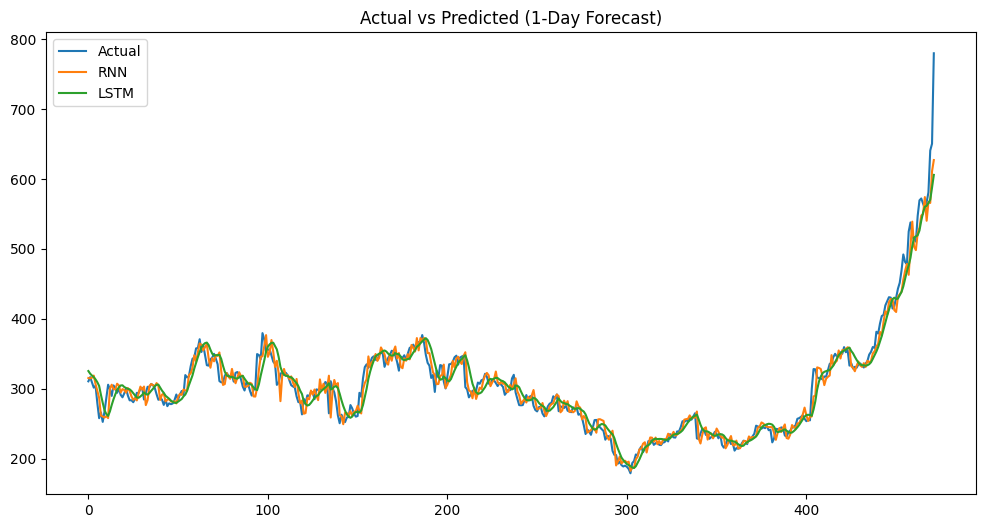

In [111]:
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Actual")
plt.plot(pred_rnn_1, label="RNN")
plt.plot(pred_lstm_1, label="LSTM")
plt.title("Actual vs Predicted (1-Day Forecast)")
plt.legend()
plt.show()

### ➤ *Final Evaluation with Tuned Models*

In [112]:
# =========================================================
# EVALUATE TUNED MODELS
# =========================================================

rnn_pred = best_rnn_model.predict(X_test)
lstm_pred = best_lstm_model.predict(X_test)

rnn_pred_inv = scaler_y_close.inverse_transform(rnn_pred)
lstm_pred_inv = scaler_y_close.inverse_transform(lstm_pred)

rnn_mse = mean_squared_error(y_test_inv, rnn_pred_inv)
lstm_mse = mean_squared_error(y_test_inv, lstm_pred_inv)

print("Tuned RNN MSE:", rnn_mse)
print("Tuned LSTM MSE:", lstm_mse)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Tuned RNN MSE: 321.1512367601293
Tuned LSTM MSE: 346.44012652432633


### ➤ *Model Saving*

Save Models & Scalers

In [113]:
model_rnn_close_1.save(PROJECT_DIR + "/rnn_close_1.h5")
model_lstm_1.save(PROJECT_DIR + "/lstm_close_1.h5")

import joblib
joblib.dump(scaler_x, PROJECT_DIR + "/scaler_x.pkl")
joblib.dump(scaler_y_close, PROJECT_DIR + "/scaler_y_close.pkl")

['/content/drive/MyDrive/Colab Notebooks/Tesla Stock Price Prediction/scaler_y_close.pkl']

## 07. Streamlit Application

### ➤ *Create Streamlit App*

In [114]:
app_code = """
import streamlit as st
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import joblib

model = load_model('lstm_close_1.h5')
scaler_x = joblib.load('scaler_x.pkl')
scaler_y = joblib.load('scaler_y_close.pkl')

st.title("Tesla Stock Price Prediction")

uploaded = st.file_uploader("Upload CSV", type=["csv"])
if uploaded:
    df = pd.read_csv(uploaded)
    data = scaler_x.transform(df[['open','high','low','volume']])
    X = np.array([data[-60:]])
    pred = model.predict(X)
    price = scaler_y.inverse_transform(pred)[0][0]
    st.success(f"Predicted Next Day Close Price: ${price:.2f}")
"""
with open("app.py", "w") as f:
    f.write(app_code)

### ➤ *Install Streamlit*

In [115]:
# =========================================================
# ENSURE STREAMLIT IS INSTALLED
# =========================================================

!pip install streamlit

### ➤ *Deploy Streamlit App*

In [ ]:
# =========================================================
# CELL 38 — DEPLOY STREAMLIT APP (NO NGROK REQUIRED)
# =========================================================

!streamlit run app.py --server.port 8501 --server.enableCORS false

2026-01-11 09:44:58.379 
'server.enableXsrfProtection=true'.
As a result, 'server.enableCORS' is being overridden to 'true'.

More information:
In order to protect against CSRF attacks, we send a cookie with each request.
To do so, we must specify allowable origins, which places a restriction on
cross-origin resource sharing.

If cross origin resource sharing is required, please disable server.enableXsrfProtection.
            



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.194.203.24:8501

